# Setup

In [1]:
import pandas as pd
import numpy as np
import re
import sklearn.preprocessing as sp
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import time
from sklearn.metrics import accuracy_score


In [2]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [518]:
import pickle

In [79]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

In [436]:
from sklearn.decomposition import PCA

In [516]:
import pandas as pd

# Data loading

In [3]:
df=pd.read_csv("../data/clean_data.csv")


In [4]:
df.drop(columns=['?'], inplace=True)
df.drop(columns=['Record_ID'], inplace=True)

In [9]:
occup_start_i= df.columns.get_loc('Occupation_Accountant')
occup_end_i=df.columns.get_loc('Occupation________')

In [11]:
df.iloc[:, occup_start_i: occup_end_i+1]=df.iloc[:, occup_start_i: occup_end_i+1].astype(int)

C:\Users\58305\AppData\Local\Temp\ipykernel_21888\3518936128.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0        0
1        0
2        0
3        0
4        0
        ..
78932    0
78933    0
78934    0
78935    0
78936    0
Name: Occupation_Accountant, Length: 78937, dtype: int32' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.iloc[:, occup_start_i: occup_end_i+1]=df.iloc[:, occup_start_i: occup_end_i+1].astype(int)
C:\Users\58305\AppData\Local\Temp\ipykernel_21888\3518936128.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0        0
1        0
2        0
3        0
4        0
        ..
78932    0
78933    0
78934    0
78935    0
78936    0
Name: Occupation_Architect, Length: 78937, dtype: int32' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.

In [13]:
#df.to_csv('S2_CleanDataset.csv', index=False)

In [15]:
X = df.drop(columns=['Credit_Score'])  # Drop 'Credit_Score' to get features
y = df['Credit_Score']  # Use 'Credit_Score' as labels



### The Class Distribution of Whole Data

<Axes: xlabel='Credit_Score'>

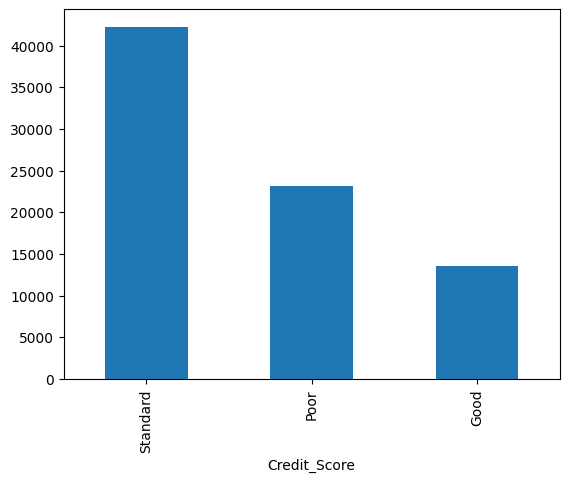

In [17]:
y.value_counts().plot(kind='bar')

# Divide the Train and Test Dataset

In [20]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Data preprocessing

## Smote the training data

In [24]:
# Smote to deal with inbalance datase
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

### The Class Distribution of Train Data after smote

<Axes: xlabel='Credit_Score'>

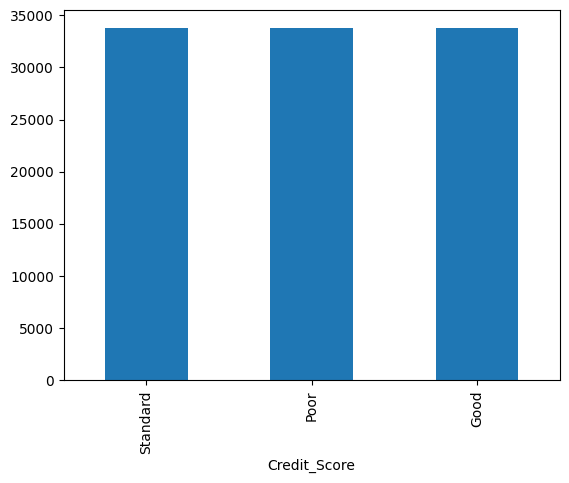

In [25]:
y_resampled.value_counts().plot(kind='bar')

### The Class Distribution of Test Data

<Axes: xlabel='Credit_Score'>

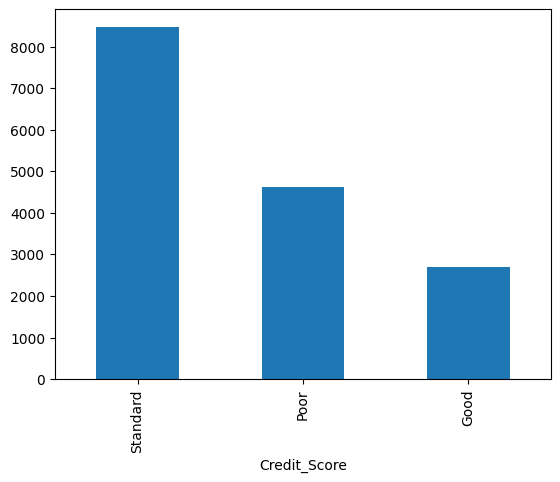

In [26]:
y_test.value_counts().plot(kind='bar')

## MinMax Noramlization of the Data

In [30]:
# Initialize the MinMaxScaler (default range is 0 to 1)
scaler = MinMaxScaler()

# Fit the scaler to your data (X_train) and transform it
X_train_scaled = scaler.fit_transform(X_train)

# If you want to apply the same transformation to test data
X_test_scaled = scaler.transform(X_test)

________________________________________________________________________________________________________________________________________________________
# Teammate (Model 1 - Random Forest)

## Unscaled Model 1 Training

In [415]:
# Initialize Random Forest model (no need for class weighting with balanced data)
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [416]:
###Evaluate the model

In [417]:
# Make predictions on the train set
y_pred = rf_model.predict(X_train)

# Evaluate the model
report = classification_report(y_train, y_pred, output_dict=True)

In [421]:
report = classification_report(y_train, y_pred, output_dict=True)

# Convert the report to a DataFrame and transpose it for better readability
report_df = pd.DataFrame(report).transpose()

# Display the classification report DataFrame
print(report_df)

              precision    recall  f1-score       support
Good           1.000000  0.999908  0.999954  10852.000000
Poor           1.000000  1.000000  1.000000  18525.000000
Standard       0.999970  1.000000  0.999985  33772.000000
accuracy       0.999984  0.999984  0.999984      0.999984
macro avg      0.999990  0.999969  0.999980  63149.000000
weighted avg   0.999984  0.999984  0.999984  63149.000000


In [423]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
report= classification_report(y_test, y_pred, output_dict=True)

In [425]:
report = classification_report(y_test, y_pred, output_dict=True)

# Convert the report to a DataFrame and transpose it for better readability
report_df = pd.DataFrame(report).transpose()

# Display the classification report DataFrame
print(report_df)

              precision    recall  f1-score       support
Good           0.730078  0.693249  0.711187   2696.000000
Poor           0.771926  0.796838  0.784184   4617.000000
Standard       0.804656  0.803422  0.804038   8475.000000
accuracy       0.782683  0.782683  0.782683      0.782683
macro avg      0.768887  0.764503  0.766470  15788.000000
weighted avg   0.782350  0.782683  0.782377  15788.000000


In [23]:
### normalized the data and re train

In [24]:
# from sklearn.preprocessing import MinMaxScaler

## Scaled Model 1 Training

In [27]:
# Initialize Random Forest model (no need for class weighting with balanced data)
rf_model_smote = RandomForestClassifier(random_state=42)

# Train the model
start_time=time.time()
rf_model_smote.fit(X_train_scaled, y_train)
end_time=time.time()

In [28]:
rf_model_smote_trainging_time=start_time-end_time
print(f'Training time: {rf_model_smote_trainging_time}s')

Training time: -17.913231134414673s


In [29]:
# Make predictions on the test set
y_pred_smote = rf_model_smote.predict(X_test_scaled)

# Evaluate the model
report_smote = classification_report(y_test, y_pred_smote, output_dict=True)

In [30]:


# Convert the report to a DataFrame and transpose it for better readability
report_df = pd.DataFrame(report_smote).transpose()

# Display the classification report DataFrame
print(report_df)

              precision    recall  f1-score       support
Good           0.740987  0.701409  0.720655   2696.000000
Poor           0.773295  0.805285  0.788966   4617.000000
Standard       0.808495  0.804012  0.806247   8475.000000
accuracy       0.786863  0.786863  0.786863      0.786863
macro avg      0.774259  0.770235  0.771956  15788.000000
weighted avg   0.786674  0.786863  0.786578  15788.000000


## Hyperparameter tuning of Model 1

In [31]:
# since by above result, we can see that after scaled the input data, the accuracy is improved from 85.00% to 85.16%
# so use the scaled data to train the model

In [32]:
# Hyperparameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],           # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],           # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],           # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],             # Minimum number of samples required to be at a leaf node
    'bootstrap': [True, False]                 # Whether bootstrap samples are used when building trees
}

In [33]:
print("NaN values in X_train_scaled:", pd.isna(X_train_scaled).sum())
print("NaN values in y_train:", pd.isna(y_train).sum())  # Use pandas isna() for Series

print("Infinite values in X_train_scaled:", np.isinf(X_train_scaled).sum())


NaN values in X_train_scaled: 0
NaN values in y_train: 0
Infinite values in X_train_scaled: 0


In [34]:
# Define the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=3)

# Fit the GridSearchCV to the training data
grid_search.fit(X_train_scaled, y_train)

# Get the best hyperparameters from GridSearchCV
best_params = grid_search.best_params_
print("Best Hyperparameters from GridSearchCV:", best_params)

Fitting 3 folds for each of 216 candidates, totalling 648 fits


C:\ProgramData\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Hyperparameters from GridSearchCV: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}


In [79]:
# Train the Random Forest model with the best parameters
best_rf_model = grid_search.best_estimator_

# Make predictions on the training data
train_predictions = best_rf_model.predict(X_train_scaled)

# Calculate the training accuracy
train_accuracy = accuracy_score(y_train, train_predictions)

print(f"Training Accuracy: {train_accuracy:.4f}")

Training Accuracy: 1.0000


In [35]:
# Make predictions on the test set
y_pred_best = best_rf_model.predict(X_test_scaled)

# Evaluate the model
report_best = classification_report(y_test, y_pred_best, output_dict=True)

# Convert the classification report to a DataFrame and print it
report_df_best = pd.DataFrame(report_best).transpose()
print(report_df_best)

              precision    recall  f1-score       support
Good           0.755070  0.704377  0.728843   2696.000000
Poor           0.779647  0.813082  0.796014   4617.000000
Standard       0.811066  0.809440  0.810252   8475.000000
accuracy       0.792564  0.792564  0.792564      0.792564
macro avg      0.781928  0.775633  0.778370  15788.000000
weighted avg   0.792316  0.792564  0.792187  15788.000000


according to above we can notice there is a significant overefitting with train accuracy =1 and test accuracy = 79.26%
to reduce the overfitting
set the bootstrap to be true
increase the min_samples_leaf and min_samples_split

In [37]:
# Hyperparameter grid for GridSearchCV
param_grid2 = {
    'n_estimators': [700, 1000, 1300],
    'max_depth': [40,50,60],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True]
}

In [39]:
# Define the Random Forest model
rf_model2 = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV for hyperparameter tuning
grid_search2 = GridSearchCV(estimator=rf_model2, param_grid=param_grid2, cv=5, n_jobs=-1, verbose=3)

# Fit the GridSearchCV to the training data
grid_search2.fit(X_train_scaled, y_train)

# Get the best hyperparameters from GridSearchCV
best_params2 = grid_search2.best_params_
print("Best Hyperparameters from GridSearchCV:", best_params2)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Hyperparameters from GridSearchCV: {'bootstrap': True, 'max_depth': 50, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 1300}


In [41]:
# Train the Random Forest model with the best parameters
best_rf_model2 = grid_search2.best_estimator_

# Make predictions on the training data
train_predictions = best_rf_model2.predict(X_train_scaled)

# Calculate the training accuracy
train_accuracy = accuracy_score(y_train, train_predictions)

print(f"Training Accuracy: {train_accuracy:.4f}")

Training Accuracy: 1.0000


In [251]:
# Make predictions on the test set
y_pred_best = best_rf_model2.predict(X_train_scaled)

# Evaluate the model
report_best = classification_report(y_train, y_pred_best, output_dict=True)

# Convert the classification report to a DataFrame and print it
report_df_best = pd.DataFrame(report_best).transpose()
print(report_df_best)

              precision  recall  f1-score  support
Good                1.0     1.0       1.0  10852.0
Poor                1.0     1.0       1.0  18525.0
Standard            1.0     1.0       1.0  33772.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0  63149.0
weighted avg        1.0     1.0       1.0  63149.0


In [42]:
# Make predictions on the test set
y_pred_best = best_rf_model2.predict(X_test_scaled)

# Evaluate the model
report_best = classification_report(y_test, y_pred_best, output_dict=True)

# Convert the classification report to a DataFrame and print it
report_df_best = pd.DataFrame(report_best).transpose()
print(report_df_best)

              precision    recall  f1-score       support
Good           0.750298  0.699926  0.724237   2696.000000
Poor           0.778220  0.804852  0.791312   4617.000000
Standard       0.808190  0.810383  0.809285   8475.000000
accuracy       0.789904  0.789904  0.789904      0.789904
macro avg      0.778903  0.771720  0.774945  15788.000000
weighted avg   0.789540  0.789904  0.789506  15788.000000


## importance feature rf

In [133]:
importances = best_rf_model2.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df.sort_values(by='Importance', ascending=False)


,Feature,Importance
13,Outstanding_Debt,0.087761
6,Interest_Rate,0.074755
44,Total_Credit_Limit,0.074383
8,Payment_Delay_Days,0.059412
10,Credit_Limit_Changes,0.055471
12,Credit_Mix,0.052836
14,Credit_History_Age,0.048366
16,Monthly_Investment,0.044303
9,Delayed_Payments,0.042532
5,Credit_Cards,0.042274


In [135]:
# Set the threshold for selecting important features
threshold = 0.02

# Filter features with importance greater than the threshold
important_features = feature_importance_df[feature_importance_df['Importance'] > threshold]['Feature'].values

In [137]:
print(important_features)

['Record_Month' 'Customer_Age' 'Annual_Income' 'Monthly_Salary'
 'Bank_Accounts' 'Credit_Cards' 'Interest_Rate' 'Loans'
 'Payment_Delay_Days' 'Delayed_Payments' 'Credit_Limit_Changes'
 'Credit_Inquiries' 'Credit_Mix' 'Outstanding_Debt' 'Credit_History_Age'
 'Min_Amount_Payment' 'Monthly_Investment' 'Payment_Behavior'
 'Total_Credit_Limit']


In [139]:
# create the train and test x of important features
X_train_important = X_train[important_features]
X_test_important = X_test[important_features]

In [141]:
# Initialize the Random Forest model
rf_model_important = RandomForestClassifier(random_state=42)

# Train the model using the important features subset
rf_model_important.fit(X_train_important, y_train)

RandomForestClassifier(random_state=42)

In [145]:
# Make predictions on the training data
train_predictions = rf_model_important.predict(X_train_important)

# Calculate the training accuracy
train_accuracy = accuracy_score(y_train, train_predictions)

print(f"Training Accuracy: {train_accuracy:.4f}")

Training Accuracy: 1.0000


In [147]:
# Evaluate the model on the test set with important features
y_pred_important = rf_model_important.predict(X_train_important)
# Print the classification report
print(classification_report(y_train, y_pred_important))

In [149]:
accuracy = accuracy_score(y_test, y_pred_important)
print(f"Accuracy with important features: {accuracy:.4f}")

# Print the classification report
print(classification_report(y_test, y_pred_important))

Accuracy with important features: 0.7759
              precision    recall  f1-score   support

        Good       0.71      0.69      0.70      2696
        Poor       0.77      0.78      0.78      4617
    Standard       0.80      0.80      0.80      8475

    accuracy                           0.78     15788
   macro avg       0.76      0.76      0.76     15788
weighted avg       0.78      0.78      0.78     15788



After train the model by important featrues, the test accuracy reduce and there is still an overfitting
Since there is always a overfitting
just choosse the model with the heighest test accuracy
best hyperparameters are Best Hyperparameters from GridSearchCV: 
{'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}

### Trian the best model

In [488]:
##re-train the model
rf_model_final= RandomForestClassifier(random_state=42, 
                                        bootstrap= False, 
                                        max_depth= None, 
                                        min_samples_leaf=1, 
                                        min_samples_split= 5, 
                                        n_estimators=300)

In [490]:
# Train the model using the important features subset
rf_model_final.fit(X_train_scaled, y_train)

RandomForestClassifier(bootstrap=False, min_samples_split=5, n_estimators=300,
                       random_state=42)

In [522]:
# Evaluate the model on the train set
y_pred_train_final = rf_model_final.predict(X_train_scaled)

accuracy = accuracy_score(y_train, y_pred_train_final)
print(f"Accuracy with test set: {accuracy:.4f}")

# Print the classification report
rf_train_classification_report=classification_report(y_train, y_pred_train_final, output_dict=True)
print(rf_train_classification_report)

Accuracy with test set: 1.0000
{'Good': {'precision': 0.9999078510873571, 'recall': 0.9999078510873571, 'f1-score': 0.9999078510873571, 'support': 10852.0}, 'Poor': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 18525.0}, 'Standard': {'precision': 0.9999703896719175, 'recall': 0.9999703896719175, 'f1-score': 0.9999703896719175, 'support': 33772.0}, 'accuracy': 0.9999683288729829, 'macro avg': {'precision': 0.9999594135864248, 'recall': 0.9999594135864248, 'f1-score': 0.9999594135864248, 'support': 63149.0}, 'weighted avg': {'precision': 0.9999683288729829, 'recall': 0.9999683288729829, 'f1-score': 0.9999683288729829, 'support': 63149.0}}


In [523]:
# Evaluate the model on the test set 
y_pred_test_final = rf_model_final.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred_test_final)
print(f"Accuracy with test set: {accuracy:.4f}")

# Print the classification report
rf_test_classification_report= classification_report(y_test, y_pred_test_final,  output_dict=True)
print(rf_test_classification_report)

Accuracy with test set: 0.7926
{'Good': {'precision': 0.7550695825049701, 'recall': 0.7043768545994066, 'f1-score': 0.7288428324697754, 'support': 2696.0}, 'Poor': {'precision': 0.7796469366562825, 'recall': 0.8130820879358891, 'f1-score': 0.7960135708227312, 'support': 4617.0}, 'Standard': {'precision': 0.811066445968314, 'recall': 0.8094395280235989, 'f1-score': 0.8102521703183133, 'support': 8475.0}, 'accuracy': 0.7925639726374462, 'macro avg': {'precision': 0.781927655043189, 'recall': 0.7756328235196315, 'f1-score': 0.7783695245369401, 'support': 15788.0}, 'weighted avg': {'precision': 0.7923160394322851, 'recall': 0.7925639726374462, 'f1-score': 0.7921866022469451, 'support': 15788.0}}


In [410]:
# Save the model to a file
with open('rf_model_final.pkl', 'wb') as model_file:
    pickle.dump(rf_model_final, model_file)

# Annie Shorya (Model 2 - XGBoost)

## Data Preprocessing for Model 2

## LabelEncoding of the Data (Model 2 - XGBoost)

In [42]:

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Encode the target variable (y_train and y_test)
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [546]:
y_resampled_encoded= label_encoder.transform(y_resampled)

# Model 2 Training with smote

In [548]:
# Initialize and train the XGBoost classifier
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_resampled, y_resampled_encoded)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
print(f"Accuracy: {accuracy_score(y_test_encoded, y_pred_xgb):.2f}")


Accuracy: 0.74


In [552]:
print(classification_report(y_test_encoded, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.63      0.71      0.67      2696
           1       0.73      0.76      0.75      4617
           2       0.80      0.75      0.77      8475

    accuracy                           0.74     15788
   macro avg       0.72      0.74      0.73     15788
weighted avg       0.75      0.74      0.75     15788



## Model 2 Training Scaled Data

In [613]:
# Initialize XGBoost classifier
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=3, random_state=42)

# Train the XGBoost model
xgb_model.fit(X_train_scaled, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=3,
              num_parallel_tree=None, ...)

In [614]:
# Evaluate the model on the test set 
y_pred_test = xgb_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred_test_final)
print(f"Accuracy with test set: {accuracy:.4f}")

# Print the classification report

print(classification_report(y_test, y_pred_test_final))

Accuracy with test set: 0.7926
              precision    recall  f1-score   support

        Good       0.76      0.70      0.73      2696
        Poor       0.78      0.81      0.80      4617
    Standard       0.81      0.81      0.81      8475

    accuracy                           0.79     15788
   macro avg       0.78      0.78      0.78     15788
weighted avg       0.79      0.79      0.79     15788



## Hyperparameter Tuning of Model 2 without PCA Scaled

In [63]:
# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 300, 500],            # Number of boosting rounds (trees)
    'max_depth': [3, 6, 10],                    # Maximum tree depth for base learners
    'learning_rate': [0.01, 0.1, 0.2],          # Learning rate (eta)
    'min_child_weight': [1, 5, 10],             # Minimum sum of instance weight (hessian) needed in a child
    'subsample': [0.6, 0.8, 1.0],               # Subsample ratio of the training instance
    'colsample_bytree': [0.6, 0.8, 1.0],        # Subsample ratio of columns when constructing each tree
    'gamma': [0, 0.1, 0.3],                     # Minimum loss reduction to make a further partition
}

In [67]:
# Initialize XGBoost classifier
xgb_model = xgb.XGBClassifier(objective="multi:softmax", num_class=3, random_state=42)


In [73]:
# Set up GridSearchCV with early stopping
grid_search = GridSearchCV(estimator=xgb_model, 
                           param_grid=param_grid, 
                           cv=5, 
                           scoring='accuracy', 
                           n_jobs=-1, 
                           verbose=3)

# Fit the model and apply early stopping during cross-validation
grid_search.fit(X_train_scaled, y_train_encoded)

# Get the best parameters and model
best_xgb_model = grid_search.best_estimator_
print(f"Best Hyperparameters from GridSearchCV: {grid_search.best_params_}")


Fitting 5 folds for each of 2187 candidates, totalling 10935 fits
Best Hyperparameters from GridSearchCV: {'colsample_bytree': 0.6, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.8}


## Evaluation of Scaled Data

In [ ]:
# re load the model
# Load the model from a .pkl file
with open('final_XGBoost_model.pkl', 'rb') as file:
    best_xgb_model = pickle.load(file)

In [527]:
# Predict on the test set with the best model
y_pred_best = best_xgb_model.predict(X_test_scaled)

# Evaluate the performance
accuracy = accuracy_score(y_test_encoded, y_pred_best)
print(f"Accuracy: {accuracy:.4f}")

# Print the classification report
xgb_test_report = classification_report(y_test_encoded, y_pred_best, output_dict=True)
print(xgb_test_report)

Accuracy: 0.7945
{'0': {'precision': 0.7631578947368421, 'recall': 0.7099406528189911, 'f1-score': 0.7355880092236741, 'support': 2696.0}, '1': {'precision': 0.7845761631612492, 'recall': 0.7998700454840806, 'f1-score': 0.7921492921492922, 'support': 4617.0}, '2': {'precision': 0.8091683191414907, 'recall': 0.8185250737463127, 'f1-score': 0.8138198029094322, 'support': 8475.0}, 'accuracy': 0.7945274892323283, 'macro avg': {'precision': 0.7856341256798607, 'recall': 0.7761119240164615, 'f1-score': 0.7805190347607995, 'support': 15788.0}, 'weighted avg': {'precision': 0.7941197956834398, 'recall': 0.7945274892323283, 'f1-score': 0.7941234725346938, 'support': 15788.0}}


# Comparing the model

                Model  Accuracy  Precision (macro avg)  Recall (macro avg)  \
0        XGBoost Test  0.794527               0.785634            0.776112   
1  RandomForest Train  0.999968               0.999959            0.999959   
2   RandomForest Test  0.792564               0.781928            0.775633   

   F1-Score (macro avg)  
0              0.780519  
1              0.999959  
2              0.778370  


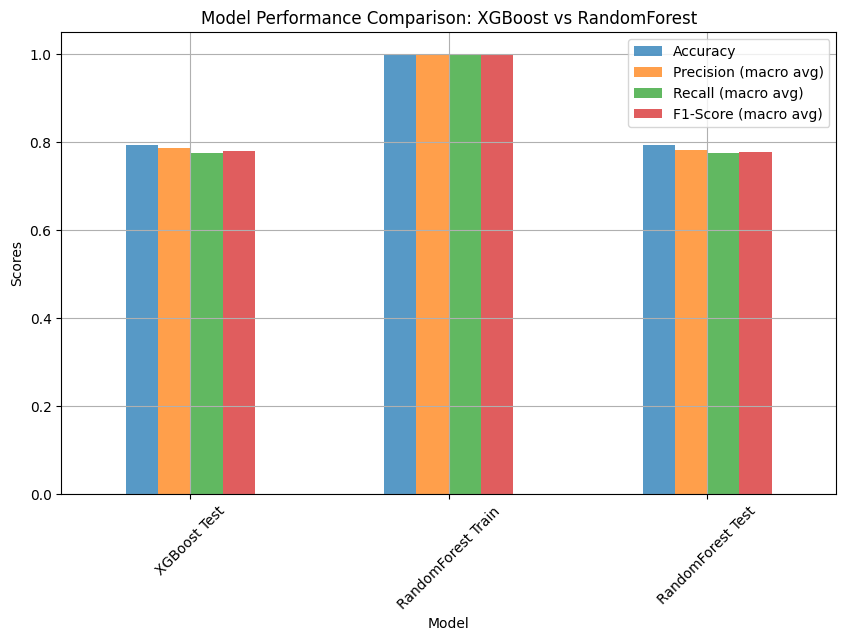

In [621]:
# Extracting metrics for comparison
comparison_data = {
    'Model': ['XGBoost Test', 'RandomForest Train', 'RandomForest Test'],
    'Accuracy': [xgb_test_report['accuracy'], rf_train_classification_report['accuracy'], rf_test_classification_report['accuracy']],
    'Precision (macro avg)': [xgb_test_report['macro avg']['precision'], rf_train_classification_report['macro avg']['precision'], rf_test_classification_report['macro avg']['precision']],
    'Recall (macro avg)': [xgb_test_report['macro avg']['recall'], rf_train_classification_report['macro avg']['recall'], rf_test_classification_report['macro avg']['recall']],
    'F1-Score (macro avg)': [xgb_test_report['macro avg']['f1-score'], rf_train_classification_report['macro avg']['f1-score'], rf_test_classification_report['macro avg']['f1-score']]
}

# Convert to DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Display the DataFrame to review
print(comparison_df)

# Plotting the comparison
comparison_df.set_index('Model', inplace=True)
comparison_df.plot(kind='bar', figsize=(10, 6), alpha=0.75)

# Customize the plot
plt.title('Model Performance Comparison: XGBoost vs RandomForest')
plt.ylabel('Scores')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()